<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/02_kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — K-Means Clustering
**Algorithm:** `sklearn.cluster.KMeans`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, itertools, time
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
FORCED_K = 4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Baseline

In [3]:
df = pd.read_csv('/content/drive/MyDrive/project/data/preprocessed_rfm_scaled.csv')
feature_cols = ['Recency_scaled', 'Frequency_log_scaled', 'Monetary_log_scaled', 'AOV_scaled', 'Return_Rate_Pct_scaled']
X = df[feature_cols].values
print(f"Feature matrix: {X.shape[0]:,} customers x {X.shape[1]} features")
df[feature_cols].head()


Feature matrix: 49,661 customers x 5 features


,Recency_scaled,Frequency_log_scaled,Monetary_log_scaled,AOV_scaled,Return_Rate_Pct_scaled
0,0.156491,-0.872192,-1.159721,-0.873317,-1.637864
1,-0.814439,0.563286,0.571692,0.027255,1.050733
2,-0.140182,-0.299803,-0.433216,-0.514450,-1.637864
3,0.844233,0.167872,-0.767006,-1.609472,0.781873
4,0.767817,0.167872,-0.368398,-1.071207,0.781873


## 2. Grid Search Implementation
Systematic loop over:
- **Cluster Count (K):** 2 - 8
- **Initialization Methods:** `k-means++` vs `random`
- **Number of Initializations (n_init):** 10, 20, 30

In [4]:
param_grid = {
    'k': list(range(2, 9)),
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
}

results = []
start = time.time()
SIL_SAMPLE = 5000
for k, init, n_init in itertools.product(param_grid['k'], param_grid['init'], param_grid['n_init']):
    model = KMeans(n_clusters=k, init=init, n_init=n_init, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    results.append({
        'k': k, 'init': init, 'n_init': n_init,
        'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch,
        'inertia': model.inertia_
    })

results_df = pd.DataFrame(results)
print(f"Grid search complete: {len(results_df)} combinations in {time.time()-start:.1f}s")
results_df.sort_values('silhouette', ascending=False).head(10)


Grid search complete: 42 combinations in 164.5s


,k,init,n_init,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,k-means++,10,0.305441,1.453082,20416.239537,175962.236945
5,2,random,30,0.305289,1.453344,20416.323707,175961.869653
4,2,random,20,0.305289,1.453344,20416.323707,175961.869653
1,2,k-means++,20,0.305011,1.453703,20416.280951,175962.085067
2,2,k-means++,30,0.305011,1.453703,20416.280951,175962.085067
3,2,random,10,0.304756,1.453540,20416.296729,175962.024945
9,3,random,10,0.279112,1.570661,15715.286435,152060.822676
8,3,k-means++,30,0.278649,1.572765,15716.323475,152056.479197
11,3,random,30,0.278649,1.572753,15716.338662,152056.402177
7,3,k-means++,20,0.275966,1.579825,15716.133827,152057.273185


## 3. Record Evaluation Metrics
Best combination by Silhouette Score (higher is better), cross-checked against Davies-Bouldin (lower is better) and Calinski-Harabasz (higher is better).

In [5]:
search_pool = results_df[results_df['k'] == FORCED_K] if FORCED_K is not None else results_df
if FORCED_K is not None:
    print(f"FORCED_K={FORCED_K}: selecting the best hyperparameters among the {len(search_pool)} "
          f"grid combinations run at K={FORCED_K} (out of {len(results_df)} total).")

best_row = search_pool.sort_values('silhouette', ascending=False).iloc[0]
best_k = int(best_row['k'])
best_init = best_row['init']
best_n_init = int(best_row['n_init'])

print("Best hyperparameters (by Silhouette Score):")
print(f"  K = {best_k}, init = {best_init}, n_init = {best_n_init}")
print(f"  Silhouette Score:        {best_row['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:    {best_row['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz Index: {best_row['calinski_harabasz']:.1f}")


FORCED_K=4: selecting the best hyperparameters among the 6 grid combinations run at K=4 (out of 42 total).
Best hyperparameters (by Silhouette Score):
  K = 4, init = random, n_init = 20
  Silhouette Score:        0.2057
  Davies-Bouldin Index:    1.4877
  Calinski-Harabasz Index: 14043.4


In [6]:
best_model = KMeans(n_clusters=best_k, init=best_init, n_init=best_n_init, random_state=RANDOM_STATE)
cluster_labels = best_model.fit_predict(X)
df['cluster'] = cluster_labels
df['cluster'].value_counts().sort_index()


,count
cluster,
0,15123
1,19446
2,9265
3,5827


## 4. Generate Visualizations
### Elbow Curve

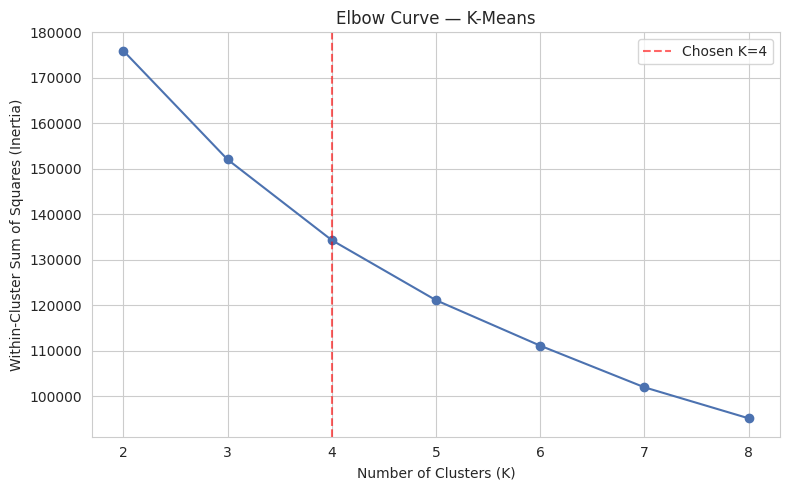

In [8]:
elbow_data = (results_df[(results_df['init'] == best_init) & (results_df['n_init'] == best_n_init)]
              .sort_values('k'))

plt.figure(figsize=(8, 5))
plt.plot(elbow_data['k'], elbow_data['inertia'], marker='o', color='#4C72B0')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'Chosen K={best_k}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Curve — K-Means')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/kmeans_elbow.png', dpi=110)
plt.show()


### Silhouette Profile Plot

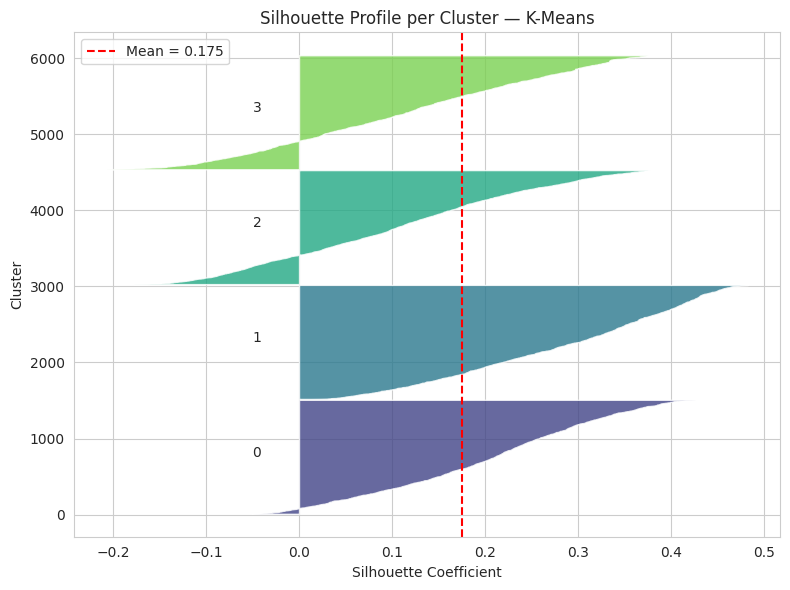

In [9]:
# silhouette_samples is also O(n^2); draw a stratified 6,000-point sample
# (proportional per cluster) purely for the visualization.
rng = np.random.RandomState(RANDOM_STATE)
plot_idx = (pd.Series(cluster_labels).groupby(cluster_labels)
            .apply(lambda s: s.sample(min(len(s), 6000 // best_k), random_state=RANDOM_STATE).index)
            .explode().astype(int).values)
X_plot, labels_plot = X[plot_idx], cluster_labels[plot_idx]
sample_scores = silhouette_samples(X_plot, labels_plot)

plt.figure(figsize=(8, 6))
y_lower = 10
colors = sns.color_palette('viridis', best_k)
for i in range(best_k):
    ith_scores = np.sort(sample_scores[labels_plot == i])
    size_i = ith_scores.shape[0]
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_scores, facecolor=colors[i], alpha=0.8)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(sample_scores.mean(), color='red', linestyle='--', label=f'Mean = {sample_scores.mean():.3f}')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.title('Silhouette Profile per Cluster — K-Means')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/kmeans_silhouette_profile.png', dpi=110)
plt.show()


### 2D PCA Scatter Plot

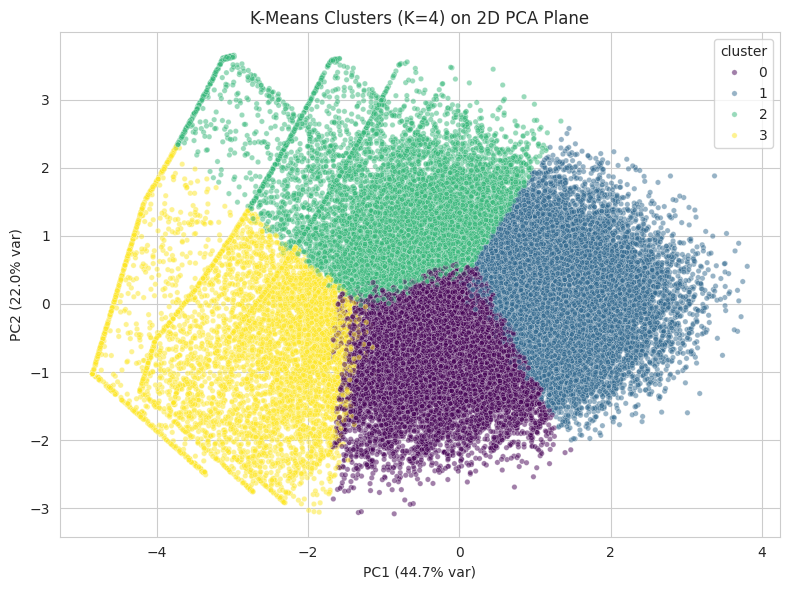

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.5, s=15, legend='full')
plt.title(f'K-Means Clusters (K={best_k}) on 2D PCA Plane')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/kmeans_pca_scatter.png', dpi=110)
plt.show()


## 5. Export Artifacts

In [13]:
joblib.dump(best_model, '/content/drive/MyDrive/project/models/kmeans_model.pkl')

kmeans_results = {
    'algorithm': 'KMeans',
    'assigned_member': 'Student 1',
    'grid_search_space': param_grid,
    'best_params': {'k': best_k, 'init': best_init, 'n_init': best_n_init},
    'best_metrics': {
        'silhouette_score': float(best_row['silhouette']),
        'davies_bouldin_index': float(best_row['davies_bouldin']),
        'calinski_harabasz_index': float(best_row['calinski_harabasz']),
        'inertia': float(best_row['inertia']),
    },
    'all_grid_results': results_df.to_dict(orient='records'),
    'cluster_sizes': df['cluster'].value_counts().sort_index().to_dict(),
}

with open('/content/drive/MyDrive/project/metrics/kmeans_results.json', 'w') as f:
    json.dump(kmeans_results, f, indent=2, default=str)

print("Saved /content/drive/MyDrive/project/models/kmeans_model.pkl and /content/drive/MyDrive/project/metrics/kmeans_results.json")


Saved /content/drive/MyDrive/project/models/kmeans_model.pkl and /content/drive/MyDrive/project/metrics/kmeans_results.json
